<style>
pre, code { white-space: pre-wrap !important; word-break: break-all !important; }
</style>

# Connected but Left Behind: Public Transport Accessibility and Unemployment Across English LSOAs
### A Machine Learning Approach to Understanding When Connectivity Fails to Translate into Economic Opportunity

**Author**: Nadia Jimena Cabrera Salazar  
**Module:** CASA0006: Data Science for Spatial Systems   
**Programme:** MSc Urban Spatial Science: CASA, UCL    
**Date:** May 2025  
**Word count**: 1550 words (only narrative text)

## 1. Introduction

Bastiaanssen et al. (2022) established that better public transport job accessibility improves individual employment probabilities in Great Britain — but only in specific contexts: urban areas with lower car ownership rates and low-income neighbourhoods. Their finding raises a harder question that their individual-level methodology could not address directly: what happens at the level of places rather than people, and at national scale across all of England? The question has direct policy relevance: the Levelling Up White Paper (HM Government, 2022) identifies transport connectivity as one of twelve missions targeting geographical disparity. Whether PT accessibility actually predicts better employment outcomes across English neighbourhoods, and under what structural conditions that relationship breaks down, is therefore an empirical question with material consequences for how levelling up is sequenced and targeted.

This study addresses that question by applying machine learning to 31,810 Lower Super Output Areas (LSOAs) across England, using the PT job accessibility index developed by Verduzco-Torres and McArthur (2024) alongside 26 structural predictors drawn from the 2021 Census, the Index of Multiple Deprivation, and the National Public Transport Access Node dataset. The analytical value of this approach lies not in predictive accuracy per se, but in interpretability: SHAP analysis (Lundberg and Lee, 2017) allows systematic mapping of where and for whom the transport-employment relationship holds — and where structural conditions overwhelm it.

Lucas (2012) argues that transport disadvantage is not an independent cause of social exclusion but a co-produced symptom of compound deprivation — and that resolving it requires addressing the structural conditions in which it is embedded, not simply improving infrastructure. If this is correct, PT accessibility should explain relatively little of unemployment variation once structural conditions are controlled for. This study tests that proposition empirically and at fine spatial resolution across all of England, extending Bastiaanssen et al.'s individual-level findings to the neighbourhood scale.


## 2. Research Question

**"To what extent is public transport job accessibility associated with lower unemployment across English LSOAs — and under what structural conditions does this association break down?"**

### Sub-questions

- **SQ1:** Is PT accessibility a significant predictor of unemployment after controlling for deprivation, demographics, and spatial structure?
- **SQ2:** How does PT accessibility rank in importance relative to structural factors?
- **SQ3:** Does the transport-unemployment relationship vary across regions and rural-urban gradients?
- **SQ4:** For which communities does high PT accessibility fail to translate into lower unemployment?

## 3. Data Sources

This project draws exclusively on open-source public data from seven sources:

| **Dataset** | **Variables** | **Source** | **Geography** | **Year** |
|---|---|---|---|---|
| PT Accessibility Indicators (AI23) | PT job accessibility index (60 min threshold) | [Verduzco-Torres & McArthur / UBDC](https://zenodo.org/records/8037156) | LSOA 2011 | 2023 |
| Index of Multiple Deprivation (IMD) | Education, health, crime and housing barriers domain scores | [DLUHC](https://www.gov.uk/government/statistics/english-indices-of-deprivation-2019) | LSOA 2011 | 2019 |
| Census 2021 | Demographic, housing tenure, labour market and transport behaviour variables | [ONS / Nomis](https://www.nomisweb.co.uk) | LSOA 2021 | 2021 |
| NaPTAN | Bus stop locations, used to derive stop density per km² | [DfT](https://naptan.app.dft.gov.uk) | Point | 2024 |
| Rural-Urban Classification | 11-fold urban-rural classification | [ONS](https://geoportal.statistics.gov.uk) | LSOA 2021 | 2021 |
| LSOA to Region Lookup | Government Office Region (9 regions) | [ONS Geoportal](https://geoportal.statistics.gov.uk) | LSOA 2021 | 2021 |
| LSOA Boundaries | Polygon geometries for spatial analysis and mapping | [ONS Geoportal](https://geoportal.statistics.gov.uk) | LSOA 2021 | 2021 |

## 4. Data Preparation

All datasets were merged on LSOA code. 1,945 LSOAs were excluded due to boundary mismatches between 2011 and 2021 definitions, yielding a final dataset of 31,810 LSOAs. 

| **Step** | **Decision** |
|---|---|
| Base geography | LSOA 2021 (England only, E01 prefix). Wales and Scotland excluded |
| Merge key | `geo_code` — left join from Census 2021 as base; all datasets joined sequentially |
| Excluded LSOAs | 1,945 dropped (5.7%)  IMD 2019 and AI23 use 2011 LSOA codes, incompatible with 2021 boundaries |
| Distance variables | Calculated from LSOA population-weighted centroids in British National Grid (EPSG:27700); 10 major city centres used for `dist_to_city_km` |
| Bus stop density | NaPTAN active bus stops (BCT type, Status=active) spatially joined to LSOA polygons; density = stop count / area km² |
| Categorical encoding | `region_name` (9 regions) and `ruc_code` (11 categories) retained as string: one-hot encoded prior to modelling |
| Target variable | `pct_unemployed` = unemployed / economically active (excl. full-time students) × 100 — Census 2021 TS066 |

## 5. Variables
27 variables are selected across 6 thematic groups.
Some candidate variables were excluded prior to modelling include three IMD composite scores (leakage risk), the 45-minute PT threshold (redundant), and commuting mode share (endogeneity).

### 5.1 Target Variable (Y)

| **Variable** | **Type** | **Description** |
|---|---|---|
| `pct_unemployed` | Continuous | Percentage of economically active residents (excluding full-time students) who are unemployed. Derived from Census 2021 TS066. Mean: 4.97%, Range: 0–27.15% |

### 5.2 Predictor Variables (X)

#### Transport Accessibility & Supply

| **Variable** | **Type** | **Description** |
|---|---|---|
| `pt_access_60_pct` | Continuous | Proportion of all GB jobs reachable by public transport within 60 minutes — primary PT accessibility measure. 60-minute threshold selected to reflect realistic commuting behaviour in England |
| `bus_stops_per_km2` | Continuous | Density of active bus stops per km² — measures physical PT infrastructure supply independent of connectivity |
| `pct_nocar` | Continuous | Percentage of households with no car or van — proxy for PT dependency and mobility deprivation |

#### Deprivation Domains

| **Variable** | **Type** | **Description** |
|---|---|---|
| `imd_education` | Continuous | IMD 2019 Education Domain score — captures skills deprivation and lack of qualifications |
| `imd_health` | Continuous | IMD 2019 Health & Disability Domain score — captures health barriers to employment |
| `imd_crime` | Continuous | IMD 2019 Crime Domain score — captures safety as a mobility and employment barrier |
| `imd_housing_barriers` | Continuous | IMD 2019 Barriers to Housing Domain score — captures housing access as economic constraint |

#### Demographics

| **Variable** | **Type** | **Description** |
|---|---|---|
| `pct_ethnicityminority` | Continuous | Percentage of residents from minority ethnic groups — captures additional labour market barriers |
| `pct_aged_16_24` | Continuous | Percentage of residents aged 16–24 — youth most vulnerable to transport poverty and unemployment |
| `pct_aged_65plus` | Continuous | Percentage of residents aged 65+ — older population less likely to be economically active |
| `pct_loneparenthousehold` | Continuous | Percentage of lone-parent households — compounded mobility and employment constraints |
| `pct_born_outside_uk` | Continuous | Percentage of residents born outside the UK — migration status as additional labour market barrier |
| `pct_level4andabove` | Continuous | Percentage with degree-level education — qualifications as moderator of transport-employment link |
| `pct_noqualif` | Continuous | Percentage with no qualifications — low skills as compounding disadvantage |
| `density` | Continuous | Population density (persons/km²) — precise urban/rural proxy |

#### Housing & Tenure

| **Variable** | **Type** | **Description** |
|---|---|---|
| `pct_social_rented` | Continuous | Percentage in social rented housing — concentrated in areas with worse economic outcomes |
| `pct_private_rented` | Continuous | Percentage in private rented housing — tenure insecurity as employment instability proxy |
| `pct_overcrowded` | Continuous | Percentage of overcrowded households — indicator of extreme housing vulnerability |

#### Labour Market

| **Variable** | **Type** | **Description** |
|---|---|---|
| `pct_part_time` | Continuous | Percentage in part-time employment — proxy for underemployment |
| `pct_selfemployed` | Continuous | Percentage self-employed — captures flexible or precarious work patterns |
| `pct_inactive` | Continuous | Percentage economically inactive — captures structural labour market detachment beyond unemployment |

#### Spatial Structure

| **Variable** | **Type** | **Description** |
|---|---|---|
| `region_name` | Categorical | Government Office Region (9 categories) — captures broad North/South and regional divides |
| `ruc_code` | Categorical | ONS Rural-Urban Classification (11 categories) — captures urban-rural gradient |
| `dist_to_london_km` | Continuous | Distance from LSOA centroid to central London — proxy for North/South divide |
| `dist_to_city_km` | Continuous | Distance from LSOA centroid to nearest major city centre — captures urban gradient |



## 6. Methodology

This project employs four methods forming a coherent analytical pipeline. The pipeline begins with Exploratory Spatial Data Analysis (ESDA) to understand distributions, spatial autocorrelation (Moran's I = 0.58) and variable relationships. 

A Random Forest regression serves as the baseline. XGBoost is selected as the main model, gradient boosting consistently outperforms Random Forest on heterogeneous tabular data , and is paired with SHAP for exact feature attributions (Celbis,2022). 

Both methods are tree-based ensembles that handle heterogeneous tabular data without distributional assumptions, thhe data type for which Grinsztajn et al. (2022) demonstrate consistent superiority over neural networks, and support exact SHAP attribution via TreeSHAP.Feature selection reduces the feature set from 42 to 27 variables. Models are evaluated using 5-fold cross-validation with RMSE and R² as primary metrics.



## 7. Exploratory Spatial Data Analysis (ESDA)

In [1]:
#Libraries not installed in the environment. Please install them before running the code.
#pip install xgboost
#pip install shap
#pip install esda

In [ ]:
#Install necesary libraries 

import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap
import shap
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from libpysal.weights import Queen
from esda.moran import Moran
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# set graphic base for maps and plots

plt.rcParams.update({
    'font.family': 'monospace',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'text.color': '#1a1a1a',
    'axes.labelcolor': '#1a1a1a',
    'xtick.color': '#1a1a1a',
    'ytick.color': '#1a1a1a',
    'axes.edgecolor': '#1a1a1a',
    'grid.color': "#e1e1e1",
    'axes.grid': True,
    'grid.alpha': 0.5,
})

C1 = "#2A0170"
C2 = "#4600B0"
C3 = "#6E3CCA"
C4 = "#9884E2"
C5 = "#E1F294"
C6 = "#C7E348"
C7 = "#B1C805"

#Load Files (Files are already preprocesed)
DATA_DIR    = Path('data')
BASE_DIR    = Path('.')
DATA_DIR    = BASE_DIR / 'data'
OUTPUTS_DIR = BASE_DIR / 'outputs'
OUTPUTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_DIR / 'master_dataset.csv')
print(f"df loaded: {len(df):,} rows x {df.shape[1]} cols")
print(f"  Unemployment rate — mean: {df['pct_unemployed'].mean():.2f}% | range: {df['pct_unemployed'].min():.2f}–{df['pct_unemployed'].max():.2f}%")
print(f"  PT accessibility  — mean: {df['pt_access_60_pct'].mean():.4f} | range: {df['pt_access_60_pct'].min():.4f}–{df['pt_access_60_pct'].max():.4f}")

gdf = gpd.read_file(DATA_DIR / 'lsoa_boundaries.geojson')
gdf = gdf.rename(columns={'LSOA21CD': 'geo_code'})
print(f"\ngdf loaded: {len(gdf):,} LSOAs | CRS: {gdf.crs}")
print(f"\nData loading complete. Ready for analysis.")

df loaded: 31,810 rows x 27 cols
  Unemployment rate — mean: 4.96% | range: 0.00–27.15%
  PT accessibility  — mean: 1.5465 | range: 0.0002–16.7001

gdf loaded: 35,672 LSOAs | CRS: EPSG:4326

Data loading complete. Ready for analysis.


### 7.1 Distributions: Unemployment Rate & PT Accessibility

Unemployment is right-skewed (mean 4.96%, range 0–27%) (Figure 1A), with London, the North East and West Midlands showing the highest medians (Figure 1B). The scatter plot reveals a weakly positive PT–unemployment relationship driven by co-location of high PT provision and deprivation in urban cores (Figure 1C).

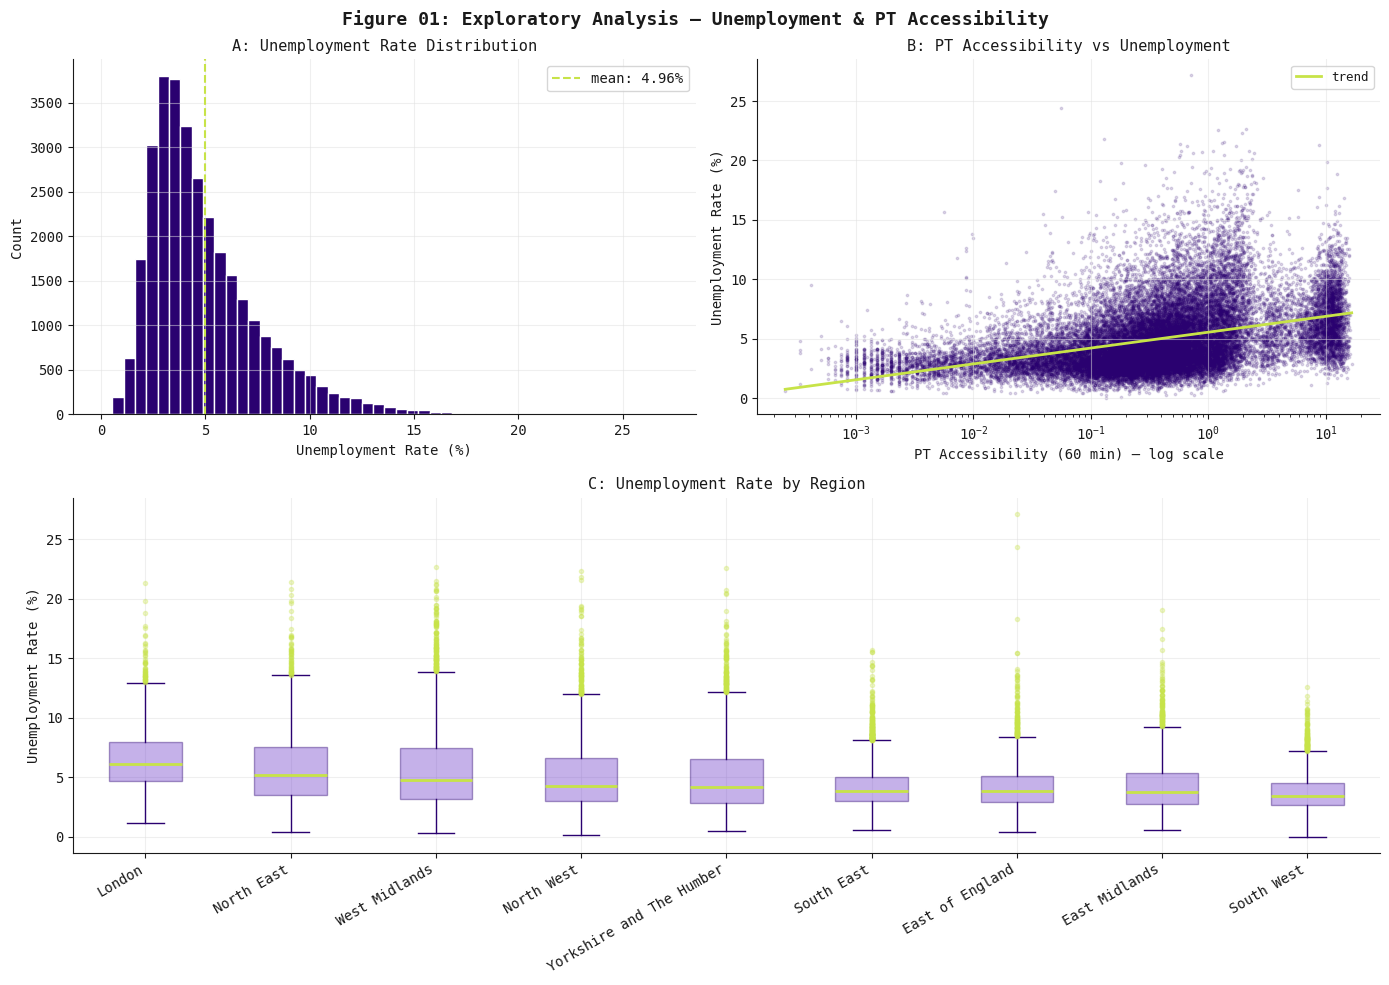

In [ ]:
fig = plt.figure(figsize=(14, 10))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 1, 2)

# Plot 1 — Unemployment distribution
ax1.hist(df['pct_unemployed'], bins=50, color=C1, edgecolor='white')
ax1.axvline(df['pct_unemployed'].mean(), color=C6, linestyle='--',
            linewidth=1.5, label=f"mean: {df['pct_unemployed'].mean():.2f}%")
ax1.set_title('A: Unemployment Rate Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Unemployment Rate (%)')
ax1.set_ylabel('Count')
ax1.legend()

# Plot 2 — Scatter PT vs Unemployment with trend
ax2.scatter(df['pt_access_60_pct'], df['pct_unemployed'],
            alpha=0.15, s=3, color=C1)
log_x = np.log(df['pt_access_60_pct'].replace(0, np.nan).dropna())
y_clean = df.loc[log_x.index, 'pct_unemployed']
z = np.polyfit(log_x, y_clean, 1)
p = np.poly1d(z)  
x_line = np.linspace(log_x.min(), log_x.max(), 300)
ax2.plot(np.exp(x_line), p(x_line), color=C6, linewidth=2, label='trend')
ax2.set_xscale('log')
ax2.set_xlabel('PT Accessibility (60 min) — log scale')
ax2.set_ylabel('Unemployment Rate (%)')
ax2.set_title('B: PT Accessibility vs Unemployment', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9)

# Plot 3 — Boxplot by region
region_order = df.groupby('region_name')['pct_unemployed'].median().sort_values(ascending=False).index.tolist()
data_ordered = [df[df['region_name'] == r]['pct_unemployed'].values for r in region_order]
ax3.boxplot(data_ordered, tick_labels=region_order, patch_artist=True,
            medianprops=dict(color=C6, linewidth=2),
            boxprops=dict(facecolor=C3, color=C1, alpha=0.4),
            whiskerprops=dict(color=C1),
            capprops=dict(color=C1),
            flierprops=dict(marker='o', markerfacecolor=C6, markeredgecolor=C6, alpha=0.3, markersize=3))
ax3.set_title('C: Unemployment Rate by Region', fontsize=14, fontweight='bold')
ax3.set_ylabel('Unemployment Rate (%)')
plt.xticks(rotation=30, ha='right')

fig.suptitle('Figure 01: Exploratory Analysis — Unemployment & PT Accessibility', fontsize=16, fontweight='bold')
for ax in [ax1, ax2, ax3]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/fig1_esda_combined.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### 7.2 Correlation Matrix
The strongest correlates of unemployment are structural: pct_nocar (r=0.71), pct_loneparenthousehold (r=0.65), pct_social_rented (r=0.65). PT accessibility correlates positively at r=0.28 — reflecting urban co-location, not a protective effect (Figure 2)

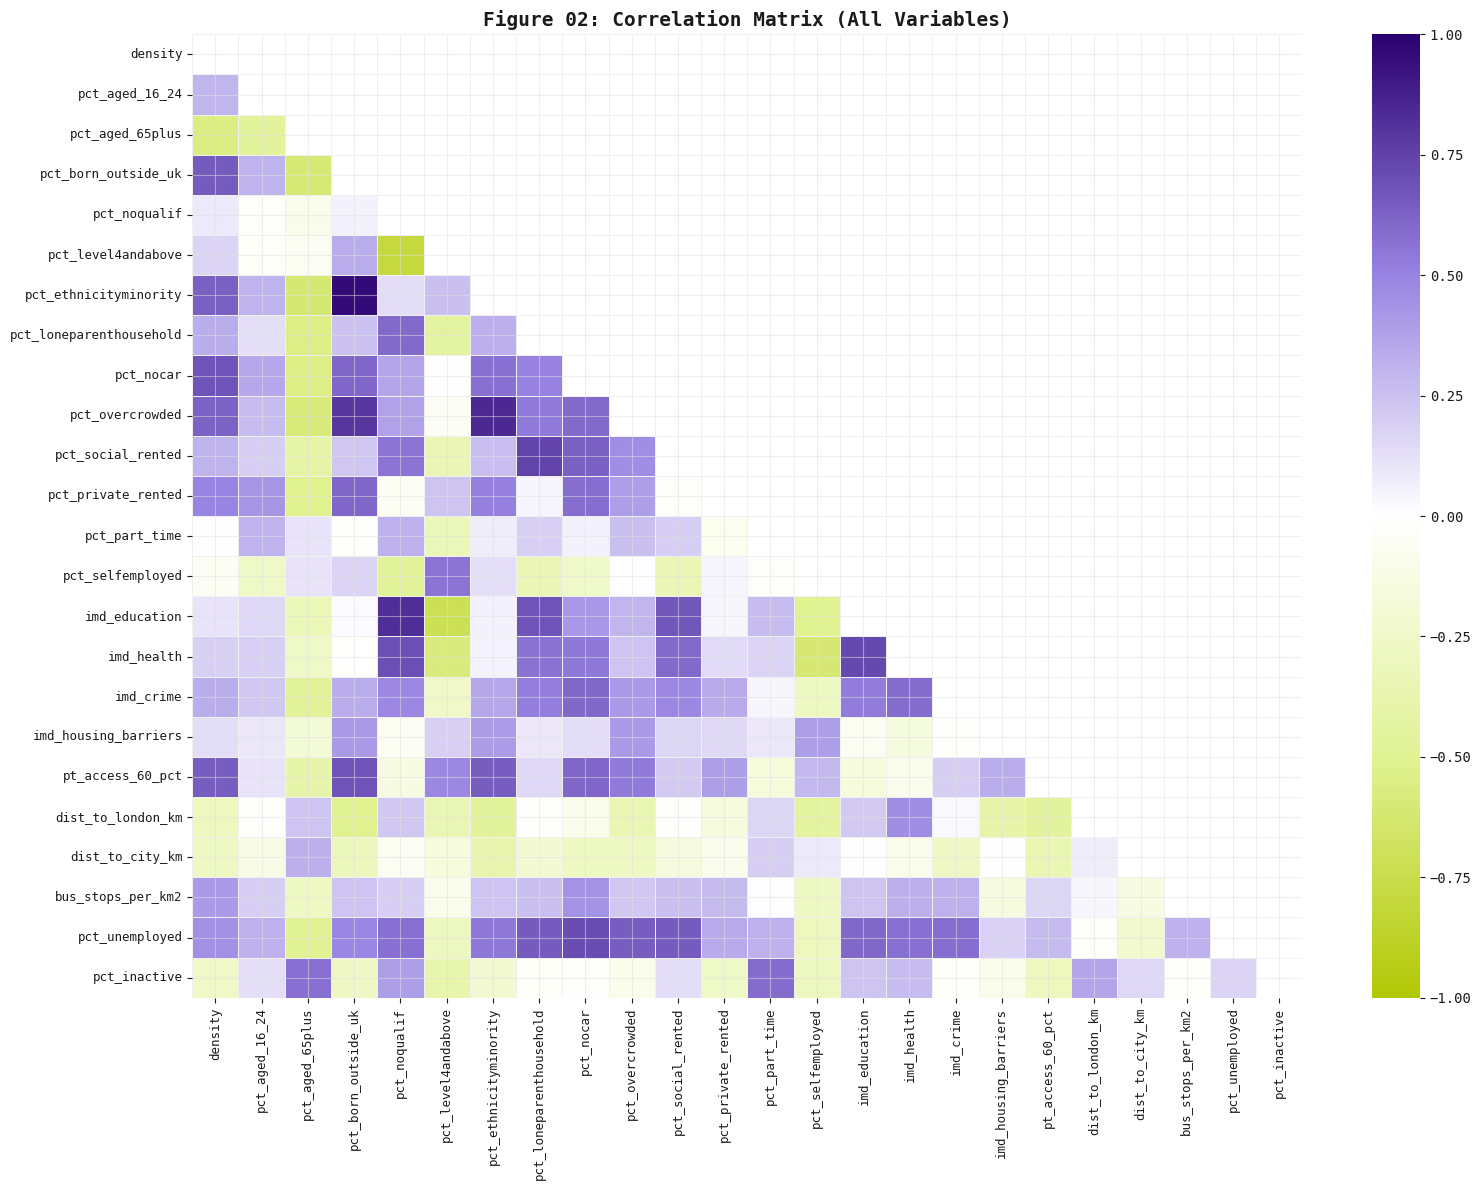


Correlations with pct_unemployed:
pct_unemployed             1.000000
pct_nocar                  0.710160
pct_loneparenthousehold    0.653040
pct_social_rented          0.651946
pct_overcrowded            0.645827
imd_education              0.603304
imd_crime                  0.582603
pct_noqualif               0.577759
imd_health                 0.573008
pct_ethnicityminority      0.546231
pct_born_outside_uk        0.486364
density                    0.452993
pct_private_rented         0.340282
pct_part_time              0.318648
pct_aged_16_24             0.318618
bus_stops_per_km2          0.313425
pt_access_60_pct           0.279948
imd_housing_barriers       0.183330
pct_inactive               0.176361
dist_to_london_km         -0.031061
dist_to_city_km           -0.221136
pct_level4andabove        -0.290875
pct_selfemployed          -0.303457
pct_aged_65plus           -0.498195


In [ ]:
custom_cmap = LinearSegmentedColormap.from_list(
    'custom_diverging', [C7, C5, 'white', C4, C1], N=256
)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12), facecolor='white')
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, mask=mask, annot=False, cmap=custom_cmap,
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, linecolor='#f0f0f0')

ax.set_title('Figure 02: Correlation Matrix (All Variables)', fontsize=17, color='#1a1a1a', fontweight='bold')
ax.tick_params(colors='#1a1a1a', labelsize=11)
plt.setp(ax.get_xticklabels(), fontfamily='monospace')
plt.setp(ax.get_yticklabels(), fontfamily='monospace')

plt.tight_layout()
plt.savefig('outputs/fig3_correlation_matrix.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\nCorrelations with pct_unemployed:")
print(corr_matrix['pct_unemployed'].sort_values(ascending=False).to_string())

### 7.3 Spatial Distribution: Choropleths
Unemployment clusters in inner London, the West Midlands, and coastal towns in the North East, areas of compound deprivation rather than poor connectivity. PT accessibility concentrates in urban cores and decays sharply outward. The visual divergence between the two maps foreshadows the central finding of this study (Figure 03).

(33755, 4)
EPSG:27700


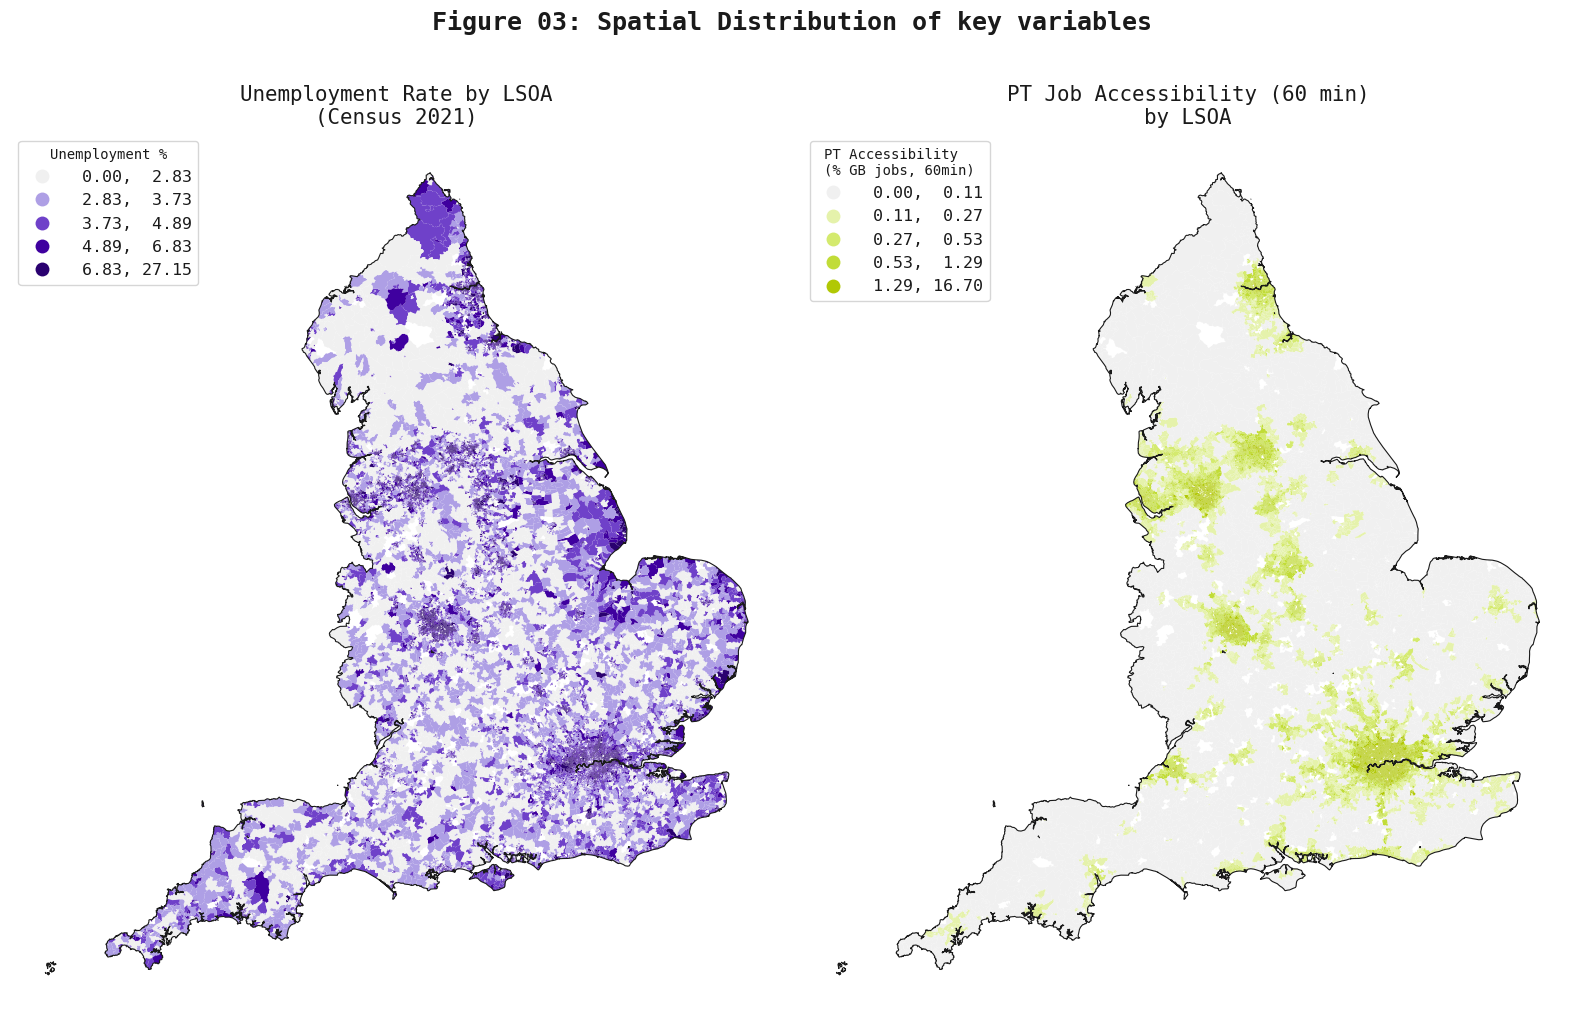

In [26]:

gdf = gdf.rename(columns={'LSOA21CD': 'geo_code'})
gdf = gdf[gdf['geo_code'].str.startswith('E01')][['geo_code', 'geometry']]
gdf = gdf.merge(df[['geo_code', 'pct_unemployed', 'pt_access_60_pct']], on='geo_code', how='left')
gdf = gdf.to_crs(epsg=27700)
england_border = gdf.dissolve()

print(gdf.shape)
print(gdf.crs)

cmap_unemployment = LinearSegmentedColormap.from_list('unemployment', ['#f0f0f0', C4, C2, C1], N=256)
cmap_accessibility = LinearSegmentedColormap.from_list('accessibility', ['#f0f0f0', C5, C6, C7], N=256)

fig, axes = plt.subplots(1, 2, figsize=(18, 10), facecolor='white')
fig.subplots_adjust(wspace=-0.3)

gdf.plot(column='pct_unemployed', ax=axes[0],
         cmap=cmap_unemployment, scheme='quantiles', k=5,
         legend=True, legend_kwds={'title': 'Unemployment %', 'loc': 'upper left', 'fontsize': 12})
england_border.boundary.plot(ax=axes[0], color='#1a1a1a', linewidth=0.8)
axes[0].set_title('Unemployment Rate by LSOA\n(Census 2021)', fontsize=15)
axes[0].axis('off')

gdf.plot(column='pt_access_60_pct', ax=axes[1],
         cmap=cmap_accessibility, scheme='quantiles', k=5,
         legend=True, legend_kwds={'title': 'PT Accessibility\n(% GB jobs, 60min)', 'loc': 'upper left', 'fontsize': 12})
england_border.boundary.plot(ax=axes[1], color='#1a1a1a', linewidth=0.8)
axes[1].set_title('PT Job Accessibility (60 min)\nby LSOA', fontsize=15)
axes[1].axis('off')

plt.suptitle('Figure 03: Spatial Distribution of key variables', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(w_pad=-3)
plt.savefig('outputs/fig4_choropleths.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### 7.4 Spatial Autocorrelation: Moran's I

Moran's I = 0.584 (p<0.001) confirms strong positive spatial clustering, motivating 5-fold cross-validation and inclusion of spatial structure variables.

In [6]:
gdf_clean = gdf.dropna(subset=['pct_unemployed']).copy().reset_index(drop=True)
w = Queen.from_dataframe(gdf_clean, use_index=False)
w.transform = 'r'

islands = [i for i, n in w.neighbors.items() if len(n) == 0]
valid = [i for i in range(len(gdf_clean)) if i not in islands]

y_sp = gdf_clean['pct_unemployed'].values
y_valid = y_sp[valid]
y_lag = np.array([np.mean(y_sp[list(w.neighbors[i])]) for i in valid])

y_dev = y_valid - y_valid.mean()
y_lag_dev = y_lag - y_lag.mean()
morans_i = np.sum(y_dev * y_lag_dev) / np.sum(y_dev ** 2)
print(f"Moran's I: {morans_i:.4f}")
print("8 coastal LSOAs excluded as spatial islands (no contiguous neighbours)")

('WARNING: ', 4439, ' is an island (no neighbors)')
('WARNING: ', 16537, ' is an island (no neighbors)')
('WARNING: ', 17877, ' is an island (no neighbors)')
('WARNING: ', 18093, ' is an island (no neighbors)')
('WARNING: ', 19505, ' is an island (no neighbors)')
('WARNING: ', 19745, ' is an island (no neighbors)')
('WARNING: ', 27267, ' is an island (no neighbors)')
('WARNING: ', 31782, ' is an island (no neighbors)')
Moran's I: 0.5841
8 coastal LSOAs excluded as spatial islands (no contiguous neighbours)


## 8. Modelling

### 8.1 Feature Preparation & Train/Test Split
Features are one-hot encoded for region_name and ruc_code, yielding 41 predictors after encoding. Data is split 80/20 (train/test, random_state=42). A decision tree probe informed the hyperparameter search ranges for both models.

In [7]:
feature_cols = [
    'pt_access_60_pct', 'bus_stops_per_km2', 'pct_nocar',
    'imd_education', 'imd_health', 'imd_crime', 'imd_housing_barriers',
    'pct_ethnicityminority', 'pct_aged_16_24', 'pct_aged_65plus',
    'pct_loneparenthousehold', 'pct_born_outside_uk',
    'pct_level4andabove', 'pct_noqualif', 'density',
    'pct_social_rented', 'pct_private_rented', 'pct_overcrowded',
    'pct_part_time', 'pct_selfemployed', 'pct_inactive',
    'dist_to_london_km', 'dist_to_city_km', 'region_name', 'ruc_code'
]

X = df[feature_cols].copy()
y = df['pct_unemployed'].copy()
X = pd.get_dummies(X, columns=['region_name', 'ruc_code'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (25448, 41), Test: (6362, 41)


In [8]:
# ── Estimate optimal max_depth before grid search ─────────────

dt_probe = DecisionTreeRegressor(random_state=42)
dt_probe.fit(X_train, y_train)

natural_depth = dt_probe.get_depth()
print(f"Natural tree depth:  {natural_depth}")
print(f"Train R²: {r2_score(y_train, dt_probe.predict(X_train)):.3f}")
print(f"Test R²:  {r2_score(y_test, dt_probe.predict(X_test)):.3f}")
print(f"\nRecommended RF max_depth range: {natural_depth//3} – {natural_depth//2}")
print(f"Recommended XGB max_depth range: 4 – {natural_depth//4}")

Natural tree depth:  40
Train R²: 1.000
Test R²:  0.600

Recommended RF max_depth range: 13 – 20
Recommended XGB max_depth range: 4 – 10


### 8.2 Random Forest and XGBoost
XGBoost outperforms the Random Forest baseline across all metrics (CV R²=0.811 vs 0.797; Test R²=0.816 vs 0.802; RMSE=1.155 vs 1.200) with notably less overfitting (Train R²=0.893 vs 0.935), confirming better generalisation and justifying its selection as the final model. The high R² is not unexpected given the inclusion of variables structurally linked to labour market outcomes, though it may partly reflect shared variance rather than independent explanatory power.

Standard 5-fold cross-validation was used rather than spatial cross-validation, as the objective is not to test generalisation to unseen regions but to analyse relationships within England. The presence of spatial autocorrelation (Moran's I=0.584) means performance metrics may be slightly optimistic; however, Moran's I computed on model residuals is 0.054, confirming that the model captures the vast majority of spatial structure and no systematic spatial bias remains (Figure 05).

In [9]:
# ── RF informed rangee ───────────────────────────────────────
param_grid_rf = {
    'n_estimators': [200],
    'max_depth': [13, 16, 20],
    'min_samples_leaf': [1, 4]
}

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=5, scoring='r2', n_jobs=-1, return_train_score=True
)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

rf_results = {
    'CV_R2': grid_rf.best_score_,
    'Train_R2': r2_score(y_train, best_rf.predict(X_train)),
    'Test_R2': r2_score(y_test, best_rf.predict(X_test)),
    'Test_RMSE': np.sqrt(mean_squared_error(y_test, best_rf.predict(X_test)))
}
print("Best RF params:", grid_rf.best_params_)
print(f"CV R²: {rf_results['CV_R2']:.3f} | Train R²: {rf_results['Train_R2']:.3f} | Test R²: {rf_results['Test_R2']:.3f} | RMSE: {rf_results['Test_RMSE']:.3f}")

Best RF params: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}
CV R²: 0.797 | Train R²: 0.967 | Test R²: 0.802 | RMSE: 1.197


In [10]:
param_grid_xgb = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [200, 300],
    'subsample': [0.7, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid_xgb,
    cv=5, scoring='r2', n_jobs=-1, return_train_score=True
)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

xgb_results = {
    'CV_R2': grid_xgb.best_score_,
    'Train_R2': r2_score(y_train, best_xgb.predict(X_train)),
    'Test_R2': r2_score(y_test, best_xgb.predict(X_test)),
    'Test_RMSE': np.sqrt(mean_squared_error(y_test, best_xgb.predict(X_test)))
}
print("Best XGB params:", grid_xgb.best_params_)
print(f"CV R²: {xgb_results['CV_R2']:.3f} | Train R²: {xgb_results['Train_R2']:.3f} | Test R²: {xgb_results['Test_R2']:.3f} | RMSE: {xgb_results['Test_RMSE']:.3f}")

results_df = pd.DataFrame({'Random Forest': rf_results, 'XGBoost': xgb_results}).T
print("\nModel Comparison:")
print(results_df.round(3))

Best XGB params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.7}
CV R²: 0.810 | Train R²: 0.892 | Test R²: 0.818 | RMSE: 1.149

Model Comparison:
               CV_R2  Train_R2  Test_R2  Test_RMSE
Random Forest  0.797     0.967    0.802      1.197
XGBoost        0.810     0.892    0.818      1.149


### 8.4 Residuals Map


count    31810.000000
mean        -0.003127
std          0.951971
min         -5.601772
25%         -0.603365
50%         -0.039642
75%          0.552770
max          9.670792
Name: residual, dtype: float64


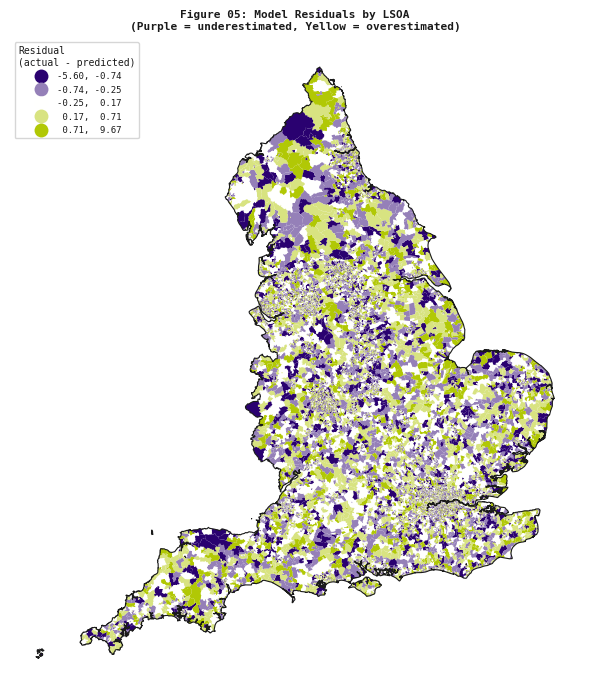

In [38]:
X_full = df[feature_cols].copy()
X_full = pd.get_dummies(X_full, columns=['region_name', 'ruc_code'], drop_first=True)
X_full = X_full.reindex(columns=X_train.columns, fill_value=0)

df['predicted'] = best_xgb.predict(X_full)
df['residual'] = df['pct_unemployed'] - df['predicted']
print(df['residual'].describe())

gdf_residual = gdf[['geo_code', 'geometry']].merge(df[['geo_code', 'residual']], on='geo_code', how='left')
cmap_residual = LinearSegmentedColormap.from_list('residual', [C1, '#ffffff', C7], N=256)

fig, ax = plt.subplots(figsize=(6, 8), facecolor='white')
gdf_residual.plot(column='residual', ax=ax,
                  cmap=cmap_residual, scheme='quantiles', k=5,
                  legend=True,
                  legend_kwds={'title': 'Residual\n(actual - predicted)', 'loc': 'upper left', 'fontsize': 6.5, 'title_fontsize': 7})
england_border.boundary.plot(ax=ax, color='#1a1a1a', linewidth=0.8)
ax.set_title('Figure 05: Model Residuals by LSOA\n(Purple = underestimated, Yellow = overestimated)', fontsize=8, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/fig_residuals_map.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [12]:

# Merge residuals into gdf
gdf_full = gdf[['geo_code', 'geometry']].merge(
    pd.DataFrame({'geo_code': df['geo_code'].values, 
                  'residual': df['pct_unemployed'].values - best_xgb.predict(X)}),
    on='geo_code', how='inner'
)

w = Queen.from_dataframe(gdf_full)
w.transform = 'r'
mi = Moran(gdf_full['residual'].values, w)
print(f"Moran's I (residuals) = {mi.I:.4f} | p = {mi.p_sim:.4f}")

('WARNING: ', 4439, ' is an island (no neighbors)')
('WARNING: ', 16537, ' is an island (no neighbors)')
('WARNING: ', 17877, ' is an island (no neighbors)')
('WARNING: ', 18093, ' is an island (no neighbors)')
('WARNING: ', 19505, ' is an island (no neighbors)')
('WARNING: ', 19745, ' is an island (no neighbors)')
('WARNING: ', 27267, ' is an island (no neighbors)')
('WARNING: ', 31782, ' is an island (no neighbors)')
Moran's I (residuals) = 0.0531 | p = 0.0010


## 9. Model Interpretation: SHAP & Permutation Importance

This study uses iterative SHAP analysis across subsets to map where and for whom the transport–employment relationship holds , and where structural conditions overwhelm it.

### 9.1 SHAP Global Analysis

Unemployment is driven primarily by structural conditions. pct_nocar dominates (mean |SHAP|=1.04), followed by overcrowding, lone parenthood and economic inactivity. PT accessibility ranks near the bottom.

This suggests that, although transport may shape potential access to opportunities, it is insufficient to translate into improved labour market outcomes in the absence of enabling social and economic conditions

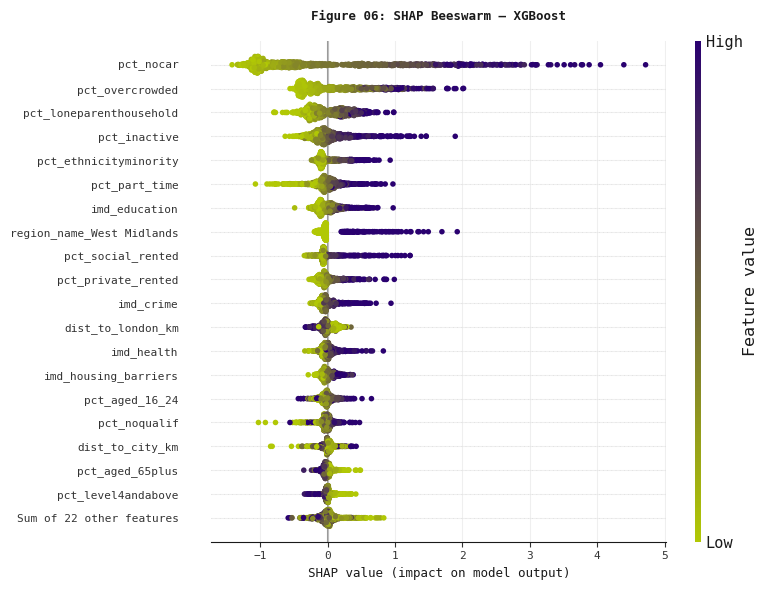

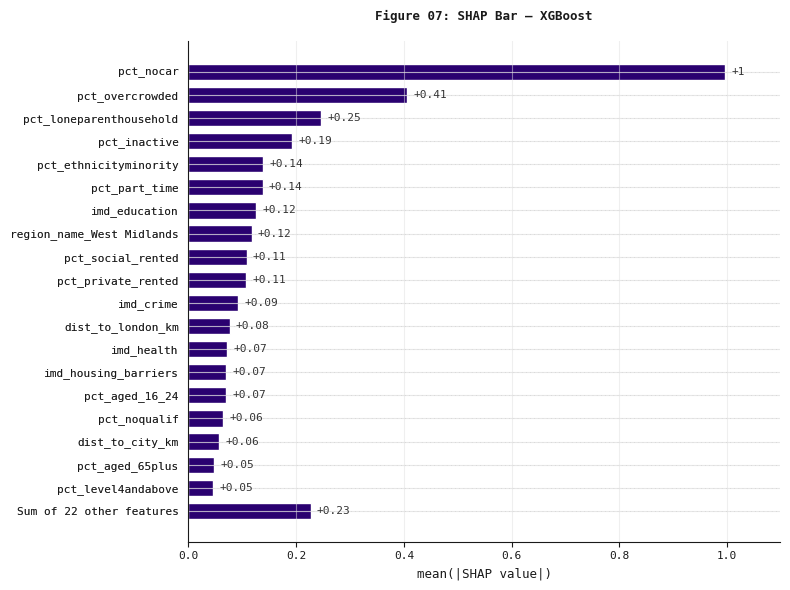

In [22]:
cmap_shap = LinearSegmentedColormap.from_list('custom', [C7, C1], N=256)

X_test_sample = X_test.sample(n=1000, random_state=42)
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer(X_test_sample)

# Beeswarm
shap.plots.beeswarm(shap_values, max_display=20, color=cmap_shap, show=False)
ax = plt.gca()
ax.tick_params(axis='both', labelsize=8)
ax.xaxis.label.set_fontsize(9)
plt.title('Figure 06: SHAP Beeswarm — XGBoost', fontsize=9, fontweight='bold', pad=15)
plt.gcf().set_size_inches(8, 6)
plt.tight_layout()
plt.savefig('outputs/shap_beeswarm.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Bar
shap.plots.bar(shap_values, max_display=20, show=False)
fig = plt.gcf()
ax = plt.gca()
for bar in ax.patches:
    bar.set_facecolor(C1)
    bar.set_edgecolor('white')
for text in ax.texts:
    text.set_color('#333333')
    text.set_fontsize(8)
ax.tick_params(axis='both', labelsize=8)
ax.xaxis.label.set_fontsize(9)
ax.spines[['top', 'right']].set_visible(False)
plt.title('Figure 07: SHAP Bar — XGBoost', fontsize=9, fontweight='bold', pad=15)
fig.set_size_inches(8, 6)
plt.tight_layout()
plt.savefig('outputs/shap_bar.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()



### 9.2 Partial Dependence Plot: PT Accessibility
Less than 0.1 percentage points of variation across the full range of pt_access_60_pct, confirming minimal marginal effect on unemployment (Figure 08)

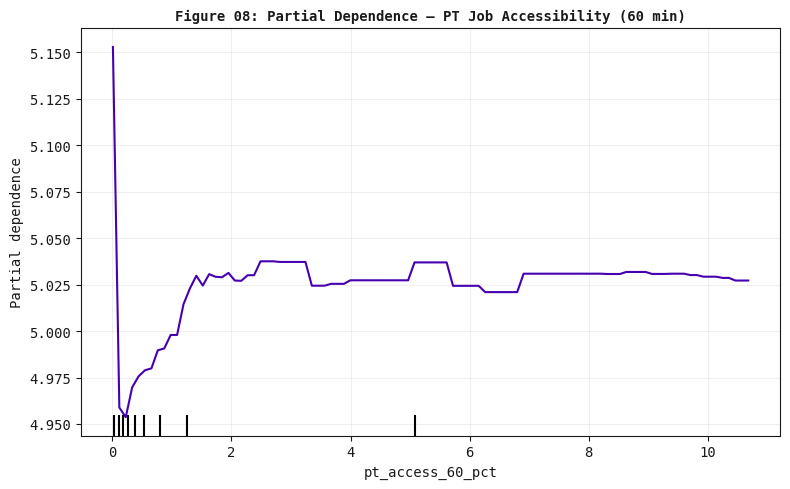

In [30]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')
PartialDependenceDisplay.from_estimator(
    best_xgb, X_test, ['pt_access_60_pct'],
    ax=ax, line_kw={'color': C2}
)
ax.set_title('Figure 08: Partial Dependence — PT Job Accessibility (60 min)', fontsize=10, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/pdp_pt_access.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### 9.3 SHAP Interaction: PT Accessibility × Car Ownership
In car-deprived LSOAs, higher PT accessibility is associated with positive SHAP values:  PT and unemployment co-locate through shared structural geography, not causation. In car-owning areas, the effect approaches zero (Figure 09). 

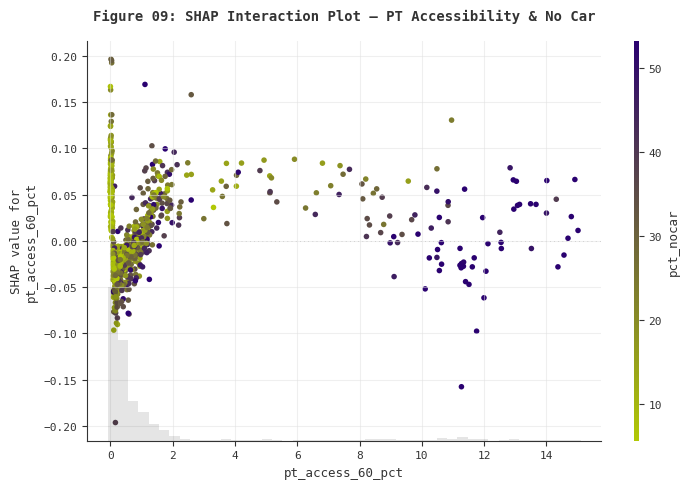

In [32]:
shap.plots.scatter(shap_values[:, 'pt_access_60_pct'], 
                   color=shap_values[:, 'pct_nocar'],
                   cmap=LinearSegmentedColormap.from_list('custom', [C7, C1], N=256),
                   show=False)
fig = plt.gcf()
ax = plt.gca()

for text in fig.texts:
    text.set_color('#333333')
ax.tick_params(colors='#333333', axis='both', labelsize=8)
ax.xaxis.label.set_color('#333333')
ax.yaxis.label.set_color('#333333')
ax.xaxis.label.set_fontsize(9)
ax.yaxis.label.set_fontsize(9)
ax.title.set_color('#333333')
for cb in fig.get_axes():
    cb.tick_params(colors='#333333', labelsize=8)
    cb.yaxis.label.set_color('#333333')
    cb.yaxis.label.set_fontsize(9)

plt.title(f'Figure 09: SHAP Interaction Plot — PT Accessibility & No Car', fontsize=10, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('outputs/shap_interaction_pt_nocar.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

## 10. Feature Selection

### 10.1 Permutation Importance and Reduced Model
Permutation importance confirms the SHAP hierarchy: pct_nocar (ΔR²=0.25) dominates, followed by pct_overcrowded (0.09) (Figure 10). Features are dropped where both permutation importance <0.001 and SHAP <0.01, removing 16 low-importance dummies and reducing the feature set from 41 to 25. Model performance is unchanged (Test R²: 0.814 → 0.816; RMSE: 1.162 → 1.157).

Computing permutation importance (10 repeats)...


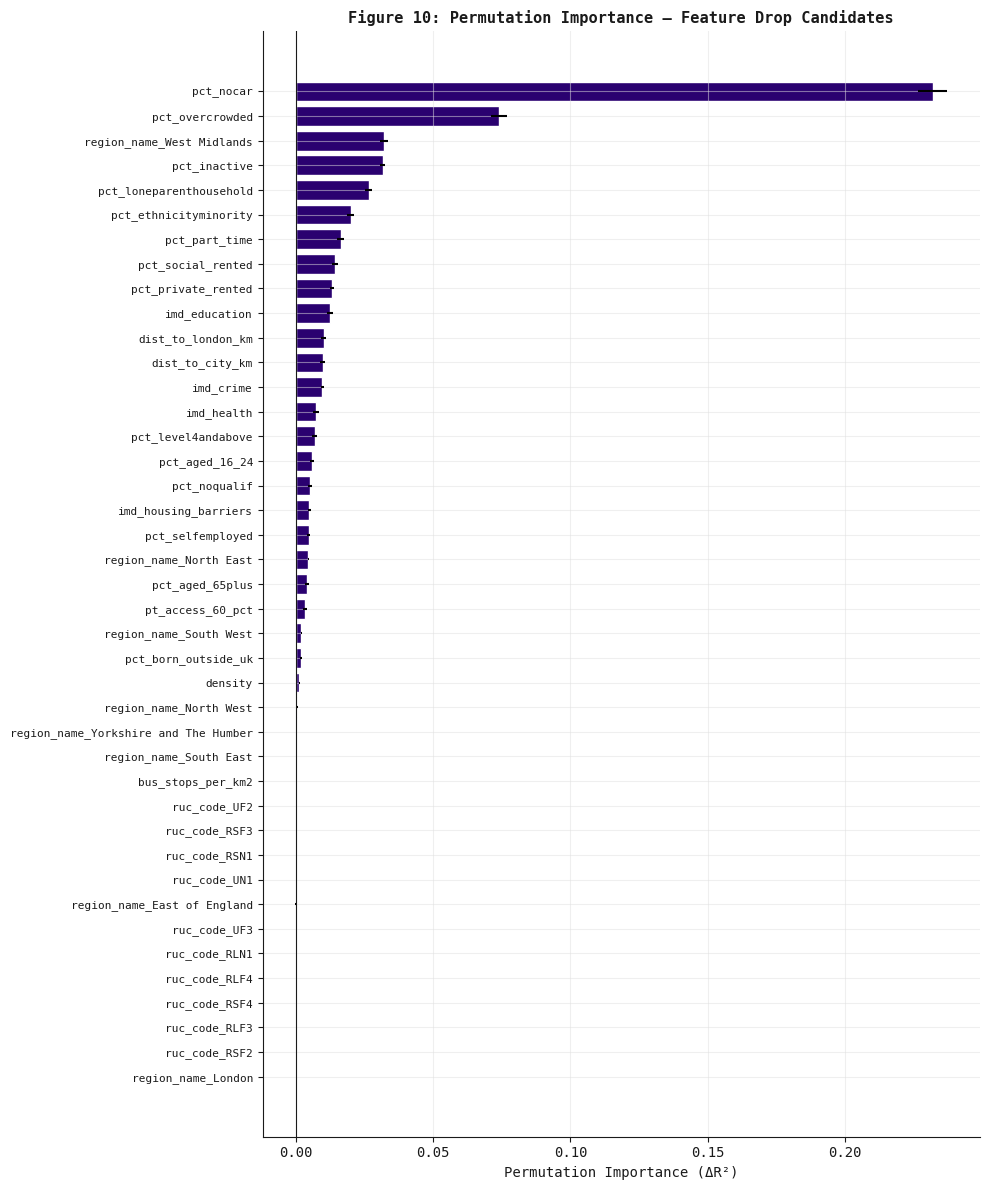

In [16]:
print("Computing permutation importance (10 repeats)...")
perm_result = permutation_importance(
    best_xgb, X_test, y_test,
    scoring='r2', n_repeats=10, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'perm_imp_mean': perm_result.importances_mean,
    'perm_imp_std': perm_result.importances_std,
}).sort_values('perm_imp_mean', ascending=False)


fig, ax = plt.subplots(figsize=(10, 12), facecolor='white')
colors = [C1 if v > 0 else C7 for v in perm_df['perm_imp_mean']]
ax.barh(range(len(perm_df)), perm_df['perm_imp_mean'],
        xerr=perm_df['perm_imp_std'], color=colors, edgecolor='white')
ax.set_yticks(range(len(perm_df)))
ax.set_yticklabels(perm_df['feature'], fontsize=8)
ax.invert_yaxis()
ax.axvline(0, color='#1a1a1a', linewidth=0.8)
ax.set_xlabel('Permutation Importance (ΔR²)')
ax.set_title('Figure 10: Permutation Importance — Feature Drop Candidates', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/permutation_importance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [17]:
comparison_df = perm_df.merge(shap_importance_df, on='feature', how='left')
drop_features = comparison_df[
    (comparison_df['perm_imp_mean'] < 0.001) &
    (comparison_df['shap_importance'] < 0.01)
]['feature'].tolist()

print(f"Features to drop: {len(drop_features)}")
print(drop_features)

X_reduced = X.drop(columns=[c for c in drop_features if c in X.columns])
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

best_xgb_reduced = XGBRegressor(random_state=42, **grid_xgb.best_params_)
best_xgb_reduced.fit(X_train_r, y_train_r)

print(f"\nOriginal features: {X.shape[1]}")
print(f"Reduced features:  {X_reduced.shape[1]}")
print(f"Original Test R²:  {r2_score(y_test, best_xgb.predict(X_test)):.3f}")
print(f"Reduced  Test R²:  {r2_score(y_test_r, best_xgb_reduced.predict(X_test_r)):.3f}")
print(f"Original RMSE:     {np.sqrt(mean_squared_error(y_test, best_xgb.predict(X_test))):.3f}")
print(f"Reduced  RMSE:     {np.sqrt(mean_squared_error(y_test_r, best_xgb_reduced.predict(X_test_r))):.3f}")

Features to drop: 15
['region_name_North West', 'region_name_Yorkshire and The Humber', 'region_name_South East', 'ruc_code_UF2', 'ruc_code_RSF3', 'ruc_code_RSN1', 'ruc_code_UN1', 'region_name_East of England', 'ruc_code_UF3', 'ruc_code_RLN1', 'ruc_code_RLF4', 'ruc_code_RSF4', 'ruc_code_RLF3', 'ruc_code_RSF2', 'region_name_London']

Original features: 41
Reduced features:  26
Original Test R²:  0.818
Reduced  Test R²:  0.817
Original RMSE:     1.149
Reduced  RMSE:     1.152


## 11. Subgroup Analysis: Where Does Connectivity Fail?

To explore what differentiates communities where PT translates into opportunity, LSOAs are grouped into four quadrants by PT accessibility and unemployment level. A vs B (same PT, different outcomes): Figure 11 shows Group A has double the car-deprivation (44% vs 19%), six times more overcrowding, seven times more social renting, and lower educational attainment. Distance to city is virtually identical, the divergence is entirely structural. C vs D (both low PT, different outcomes): Group D combines poor connectivity with structural deprivation, education deprivation 51% vs 11% in C, car-deprivation 31% vs 9%. 

PT accessibility is neither necessary nor sufficient for low unemployment. The structural conditions that differentiate Groups A and B, not distance, not connectivity, determine whether PT translates into opportunity, consistent with Lucas's (2012) argument that transport disadvantage is a symptom of compound deprivation rather than an independent cause.


In [18]:
pt_high = df['pt_access_60_pct'] > df['pt_access_60_pct'].quantile(0.75)
pt_low  = df['pt_access_60_pct'] < df['pt_access_60_pct'].quantile(0.25)
unemp_high = df['pct_unemployed'] > df['pct_unemployed'].quantile(0.75)
unemp_low  = df['pct_unemployed'] < df['pct_unemployed'].quantile(0.25)

group_A = df[pt_high & unemp_high]  # Paradox: high PT, high unemployment
group_B = df[pt_high & unemp_low]   # Success: high PT, low unemployment
group_C = df[pt_low  & unemp_low]   # Rural prosperity: low PT, low unemployment
group_D = df[pt_low  & unemp_high]  # Disconnected: low PT, high unemployment

print(f"Group A — High PT, High Unemployment: {len(group_A):,} LSOAs")
print(f"Group B — High PT, Low Unemployment:  {len(group_B):,} LSOAs")
print(f"Group C — Low PT,  Low Unemployment:  {len(group_C):,} LSOAs")
print(f"Group D — Low PT,  High Unemployment: {len(group_D):,} LSOAs")

Group A — High PT, High Unemployment: 3,868 LSOAs
Group B — High PT, Low Unemployment:  568 LSOAs
Group C — Low PT,  Low Unemployment:  3,438 LSOAs
Group D — Low PT,  High Unemployment: 603 LSOAs


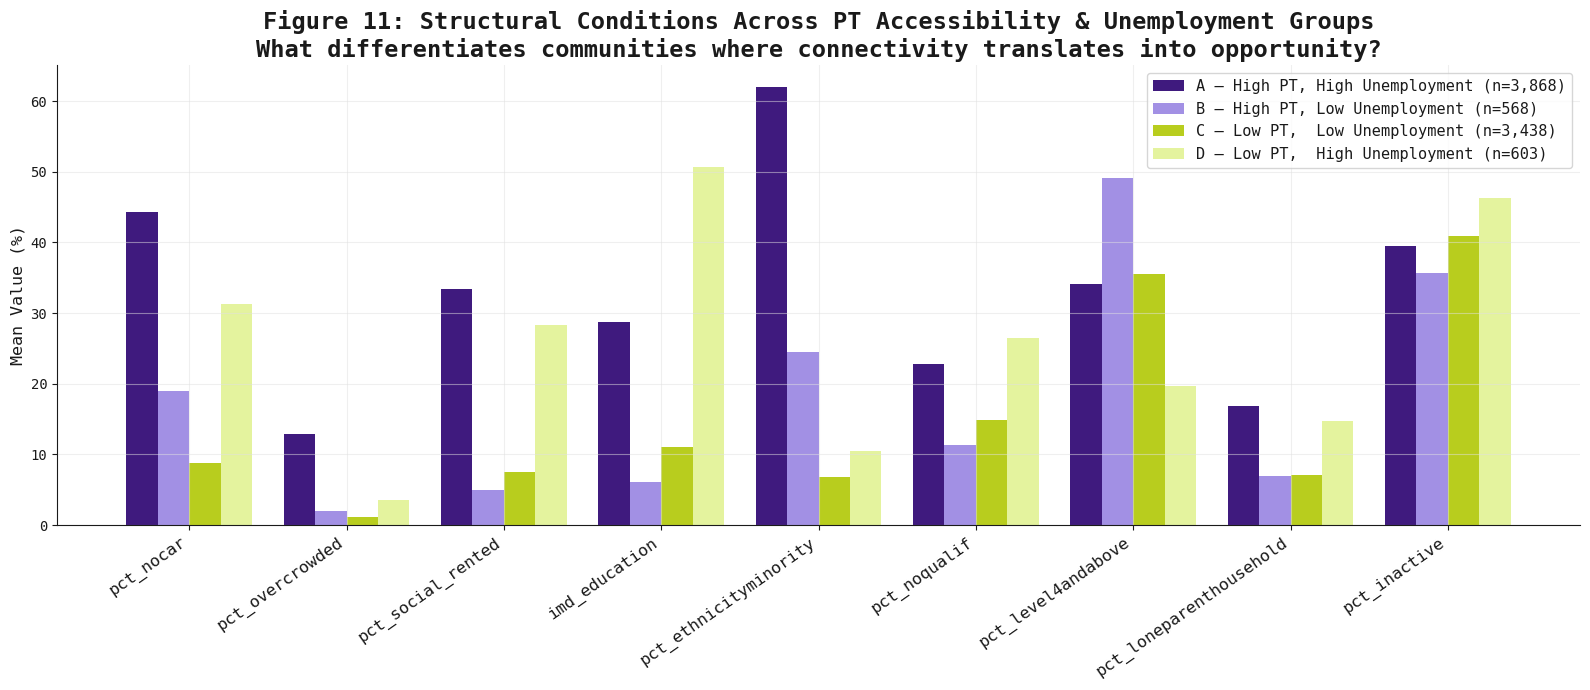

In [35]:
plot_vars = ['pct_nocar', 'pct_overcrowded', 'pct_social_rented',
             'imd_education', 'pct_ethnicityminority', 'pct_noqualif',
             'pct_level4andabove', 'pct_loneparenthousehold', 'pct_inactive']

x = np.arange(len(plot_vars))
width = 0.2

fig, ax = plt.subplots(figsize=(16, 7), facecolor='white')
ax.bar(x - width*1.5, group_A[plot_vars].mean().values, width,
       label=f'A — High PT, High Unemployment (n={len(group_A):,})', color=C1, alpha=0.9)
ax.bar(x - width*0.5, group_B[plot_vars].mean().values, width,
       label=f'B — High PT, Low Unemployment (n={len(group_B):,})',  color=C4, alpha=0.9)
ax.bar(x + width*0.5, group_C[plot_vars].mean().values, width,
       label=f'C — Low PT,  Low Unemployment (n={len(group_C):,})',  color=C7, alpha=0.9)
ax.bar(x + width*1.5, group_D[plot_vars].mean().values, width,
       label=f'D — Low PT,  High Unemployment (n={len(group_D):,})', color=C5, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(plot_vars, rotation=35, ha='right', fontsize=12)
ax.set_ylabel('Mean Value (%)', fontsize=12)
ax.set_title('Figure 11: Structural Conditions Across PT Accessibility & Unemployment Groups\n'
             'What differentiates communities where connectivity translates into opportunity?',
             fontsize=17, fontweight='bold')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/fig_four_groups.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 12. Discussion

The central finding is clear: PT job accessibility is a statistically real but structurally marginal predictor of unemployment. With a mean |SHAP| of 0.026 and a rank of #22 out of 27 features, PT accessibility is dwarfed by compound deprivation indicators. The partial consistency with Bastiaanssen et al. (2022) is analytically important,  they find PT accessibility improves individual employment probabilities in urban areas with low car ownership, but not in London, where unemployed residents concentrate in social housing near high-PT city centres. This study replicates that paradox at national scale. 

The four-group analysis confirms that PT accessibility is neither necessary nor sufficient. These findings speak directly to the Levelling Up agenda: the transport mission is unlikely to reduce unemployment in the most deprived communities unless co-delivered with the skills, health and housing missions the White Paper identifies as interdependent.

## 13. Limitations

This study has four principal limitationss. First, the cross-sectional design precludes causal inference. Second, the 2011/2021 LSOA boundary mismatch required excluding 1,945 areas. Third, spatial aggregation at LSOA level dilutes individual-level PT effects. Fourth, variables capturing transport cost and service frequency, identified by Lucas (2012) and Bastiaanssen et al. as important moderators,  are absent from the dataset, and can be a logical next step to evaluate.

## 14. Conclusion

This study applied XGBoost and SHAP to 31,810 English LSOAs to examine whether PT job accessibility predicts unemployment. Structural conditions (car-deprivation, overcrowding, lone parenthood, educatio) overwhelmingly dominate prediction, while PT accessibility ranks 21st of 27 features. The relationship breaks down most severely in deprived urban communities, where PT and unemployment co-locate through shared structural geography.

The broader implication is that transport investment alone cannot close the employment gap in England's most deprived communities. Effective policy must address the structural conditions that prevent transport access from translating into economic opportunity, precisely the interdependence the Levelling Up White Paper's own framework acknowledges but its mission-by-mission implementation risks overlooking.

## 15. References


Bastiaanssen, J., Johnson, D. and Lucas, K. (2022) 'Does better job accessibility help people gain employment? The role of public transport in Great Britain', *Urban Studies*, 59(2), pp. 301–322. doi:10.1177/00420980211012635

Beatty, C. and Fothergill, S. (2020) 'The long shadow of job loss: Britain's older industrial towns in the 21st century', *Frontiers in Sociology*, 5. doi:10.3389/fsoc.2020.00054

Celbiş, M.G. (2023) 'Unemployment in rural Europe: a machine learning perspective', *Applied Spatial Analysis and Policy*, 16(3), pp. 1071–1095. doi:10.1007/s12061-022-09464-0

Grinsztajn, L., Oyallon, E. and Varoquaux, G. (2022) 'Why do tree-based models still outperform deep learning on typical tabular data?', *Advances in Neural Information Processing Systems*, 35, pp. 507–520.

HM Government (2022) *Levelling up the United Kingdom*. London: Department for Levelling Up, Housing and Communities. Available at: https://www.gov.uk/government/publications/levelling-up-the-united-kingdom

Lucas, K. (2012) 'Transport and social exclusion: where are we now?', *Transport Policy*, 20, pp. 105–113. doi:10.1016/j.tranpol.2012.01.013

Lundberg, S.M. and Lee, S.I. (2017) 'A unified approach to interpreting model predictions', *Advances in Neural Information Processing Systems*, 30.

Verduzco Torres, J.R. and McArthur, D.P. (2024) 'Public transport accessibility indicators to urban and regional services in Great Britain', *Scientific Data*, 11. doi:10.1038/s41597-023-02890-w